In [2]:
import pandas as pd
import numpy as np
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.decomposition import PCA

### Section 01 - Linear regression for Predicting Heights

In [3]:
heights = pd.read_csv("height.csv",
usecols=['height', 'sex', 'mother', 'father']).dropna()
heights['sex'] = heights['sex'].str.upper()
heights.loc[heights['sex'] == 'W', 'sex'] = 'F'
print(heights)

     height sex  mother  father
0       150   F   170.0   177.0
1       152   F   157.0   175.0
2       152   F   155.0   156.0
3       153   F   155.0   175.0
4       153   F   150.0   176.0
..      ...  ..     ...     ...
553     197   M   183.0   190.0
554     197   M   175.0   189.0
555     197   M   163.0   192.0
556     204   M   180.0   184.0
557     173   M   155.0   180.0

[545 rows x 4 columns]


1. Let’s focus on one sex. Fit a linear model for each male’s height given the father’s height. Then, fit
another linear model for the father’s height given each male’s height.

In [4]:
import statsmodels.formula.api as sm

males = heights[heights['sex'] == 'M']

print('Model 1: height ~ father')
fit1 = sm.ols('height ~ father', data = males).fit()
print(fit1.summary2().tables[1])

(ggplot(males, aes(x='father', y='height'))
+ geom_point(alpha=0.5)
+ geom_smooth(method='lm', color='blue')
+ theme(figure_size=(3, 1.5))
).draw()

print('Model 2: father ~ height')
fit2 = sm.ols('father ~ height', data = males).fit()
print(fit2.summary2().tables[1])


Model 1: height ~ father
               Coef.  Std.Err.          t         P>|t|     [0.025      0.975]
Intercept  93.983299  8.403878  11.183325  2.507584e-24  77.442003  110.524596
father      0.488549  0.047318  10.324824  1.895175e-21   0.395413    0.581684
Model 2: father ~ height
               Coef.  Std.Err.          t         P>|t|     [0.025     0.975]
Intercept  77.024150  9.733204   7.913545  5.530516e-14  57.866351  96.181949
height      0.555783  0.053830  10.324824  1.895175e-21   0.449830   0.661736


2. Predict each male student’s height given the father’s height (predict()) and predict each father’s
height given each male student’s height. Store both predictions into new columns of a data table. Then,
plot the original data and additionally both regression lines. Hint: use geom_line

In [5]:
males["predicted_student_height"] = fit1.predict(males)
males["predicted_father_height"] = fit2.predict(males)
males

/tmp/ipykernel_5195/2705380277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_5195/2705380277.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,height,sex,mother,father,predicted_student_height,predicted_father_height
10,155,M,170.0,173.0,178.502205,163.170479
69,163,M,150.0,168.0,176.059462,167.616741
82,163,M,155.0,162.0,173.128170,167.616741
111,164,M,161.0,193.0,188.273176,168.172524
124,165,M,157.0,178.0,180.944947,168.728307
...,...,...,...,...,...,...
553,197,M,183.0,190.0,186.807531,186.513355
554,197,M,175.0,189.0,186.318982,186.513355
555,197,M,163.0,192.0,187.784628,186.513355
556,204,M,180.0,184.0,183.876239,190.403835


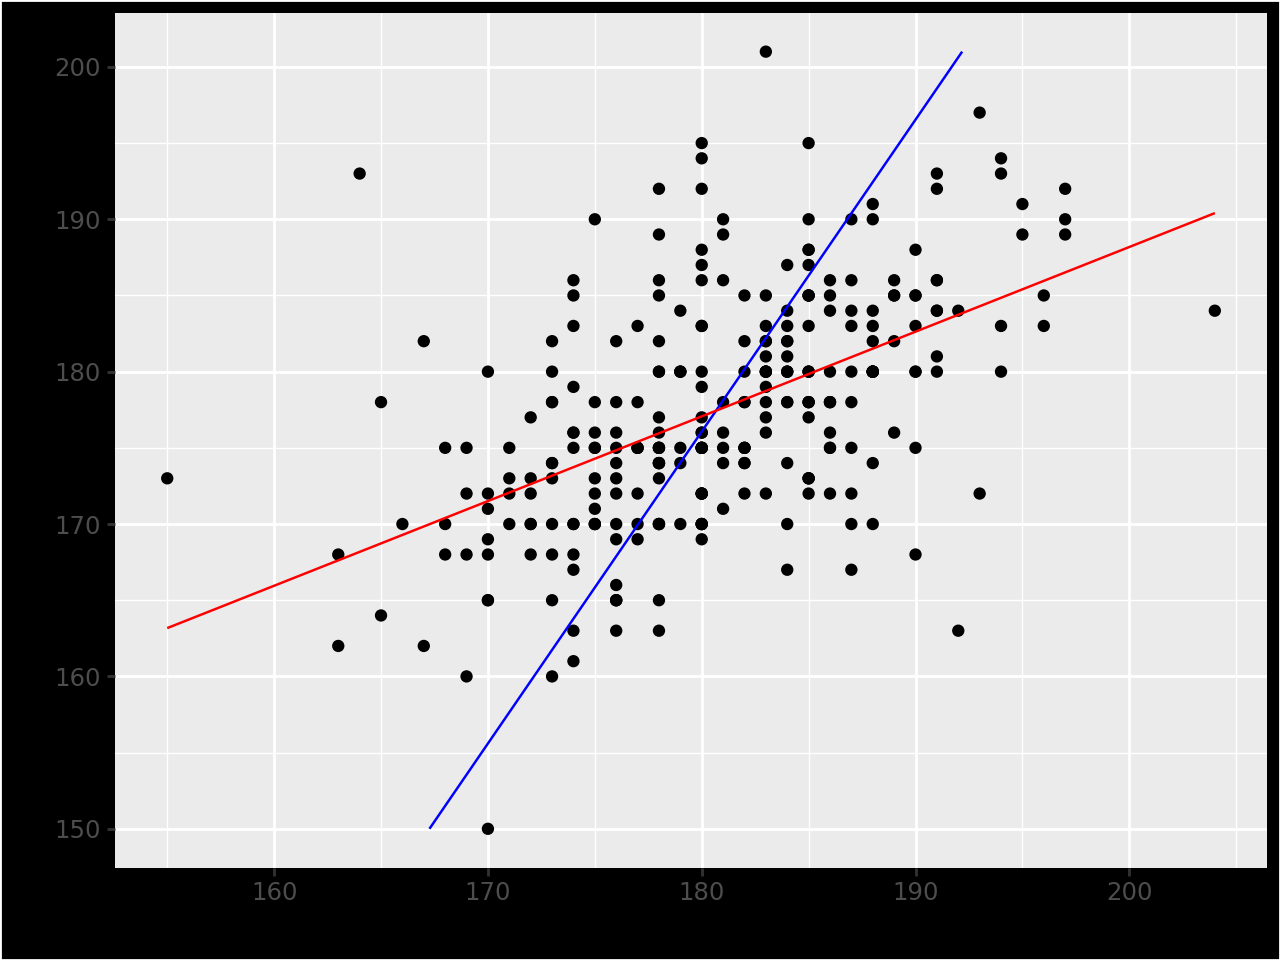

In [6]:
ggplot(males, aes(x = 'height', y = 'father')) + geom_point() + geom_line(aes(x = 'predicted_student_height', y = 'father'), color="blue") + geom_line(aes(x = 'height', y = 'predicted_father_height'), color="red")

3. Additionally, run a PCA on the same subset of the data and plot the first principal component line
into the same figure. Hint: you can get the unit vector of the first principal component by accessing
the components_ attribute of the object obtained from PCA. Given this unit vector compute the slope
and intercept and use geom_abline to plot the resulting line. Remember that the slope, 𝑚, of a line
can be calculated from the coordinates (𝑢𝑥
, 𝑢𝑦
) of its unit vector, 𝑚 = 𝑢𝑦 / 𝑢𝑥
and recall that the principal
component line contains the center of the data. Use geom_abline to plot the line from the computed
intercept and slope.

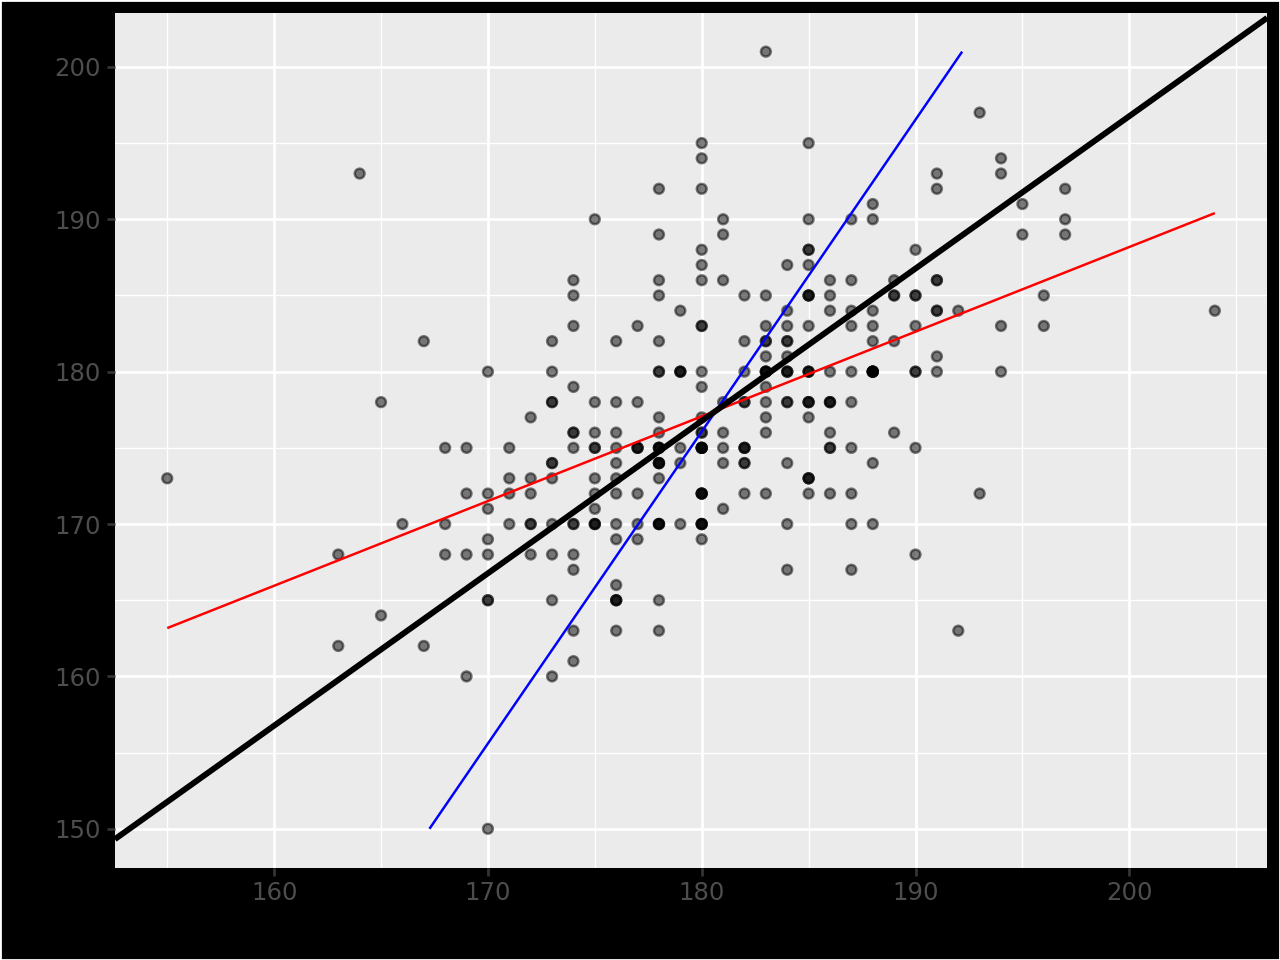

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

subset_males = males[['height', 'father']].dropna()
males_scaled = scaler.fit_transform(subset_males)
pca_males = PCA()
pca_males.fit(males_scaled)
components = pca_males.components_
ux, uy = components[0]

m = uy / ux
xbar, ybar = subset_males.mean(axis=0)
b = ybar - m * xbar
(
ggplot(males, aes(x='height', y='father'))
+ geom_point(alpha=0.5)
+ geom_line(aes(x='predicted_student_height', y='father'), color='blue')
+ geom_line(aes(x='height', y='predicted_father_height'), color='red')
+ geom_abline(
    slope=m,
    intercept=b,
    color='black',
    size=1.2
)
)

# As we can see the 2-dimensional PCA takes into account the orthogonal distance
# from points as linear regression simply calculates the two different lines,
# one according to the vertical difference and the other according to the horizontal difference.



5. For the model predicting each male height given the father’s height, check the plot of the residual
vs the predicted values and the Q-Q plot of the residuals. Do these plots provide evidence against the
assumptions of linear regression?

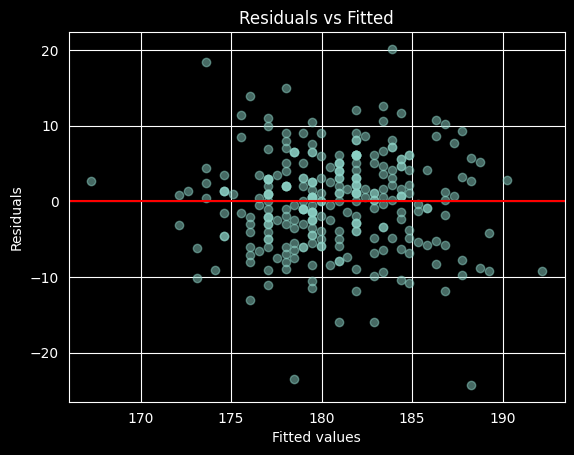

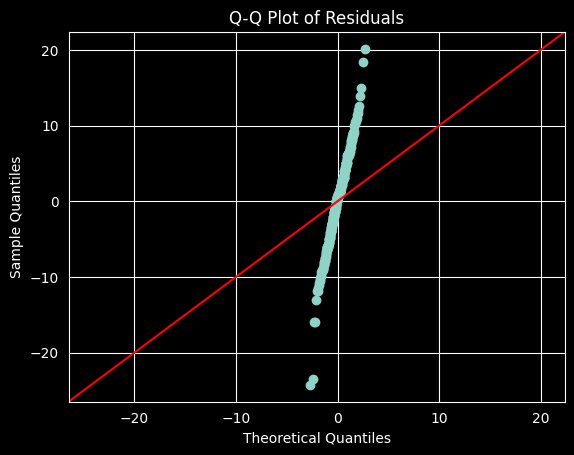

In [8]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.scatter(fit1.fittedvalues, fit1.resid, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

sm.qqplot(fit1.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

We seem to find that there is no significant correlation here as R^2 is almost 0. Residuals seem to not be well approximated by a normal distribution. The father's height seems to provide little explanatory power.

# Section 3
Colleagues tell you that they investigated the relationship between brain weight and body weight across
animals provided in the Animals dataset of the MASS library and did not find a significant association.
This is surprising. You will now investigate.

In [11]:
# Load dataset from R
animals = sm.datasets.get_rdataset("Animals", "MASS").data
dt = pd.DataFrame({
'name': animals.index,
'body_weight': animals['body'],
'brain_weight': animals['brain']
})
dt

,name,body_weight,brain_weight
rownames,,,
Mountain beaver,Mountain beaver,1.350,8.1
Cow,Cow,465.000,423.0
Grey wolf,Grey wolf,36.330,119.5
Goat,Goat,27.660,115.0
Guinea pig,Guinea pig,1.040,5.5
Dipliodocus,Dipliodocus,11700.000,50.0
Asian elephant,Asian elephant,2547.000,4603.0
Donkey,Donkey,187.100,419.0
Horse,Horse,521.000,655.0


1. Their analysis was based on a linear regression of brain_weight as response variable against
body_weight as explanatory variable and tetsing for the slope to be 0. Reproduce their observation.

In [12]:
## We start by running a simple linear regression and call summary()
## We find that the slope is not statistically significant.
## Also, it is mildly negative which is counter-intuitive.
fit = smf.ols('brain_weight ~ body_weight', data=dt).fit()
print(fit.summary2().tables[1])

                  Coef.    Std.Err.         t     P>|t|     [0.025  \
Intercept    576.372440  265.912103  2.167530  0.039536  29.782284   
body_weight   -0.000433    0.015885 -0.027235  0.978480  -0.033085   

                  0.975]  
Intercept    1122.962597  
body_weight     0.032220  


2. As usual, you decide to do some plotting to first understand the data. What plot(s) do you consider?
Create them and discuss a transformation of the data that could be helpful

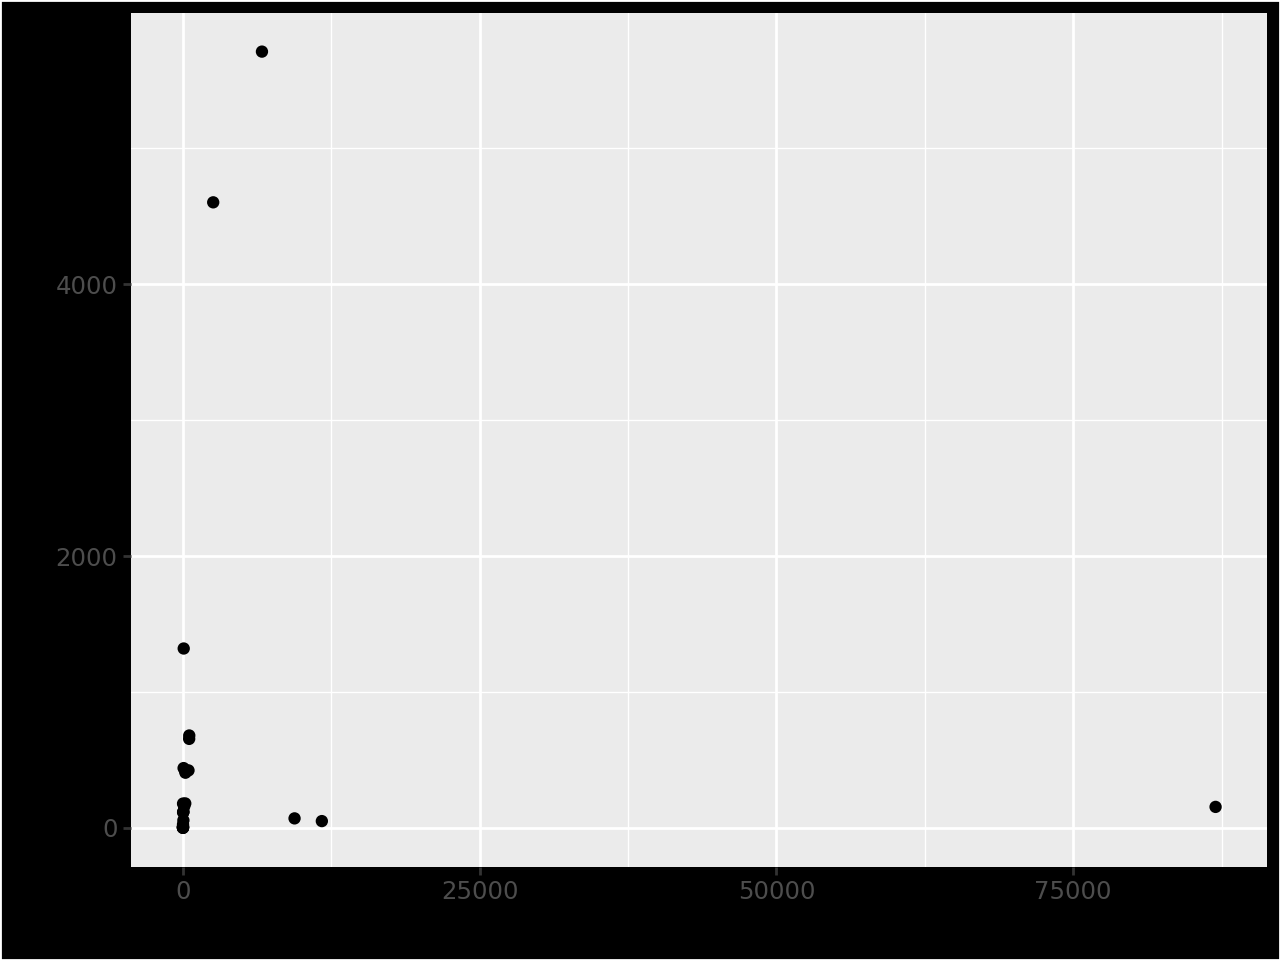

In [13]:
# Plotting the dependent variable against the independent one
(ggplot(dt, aes(x='body_weight', y='brain_weight')) +
geom_point()).show()

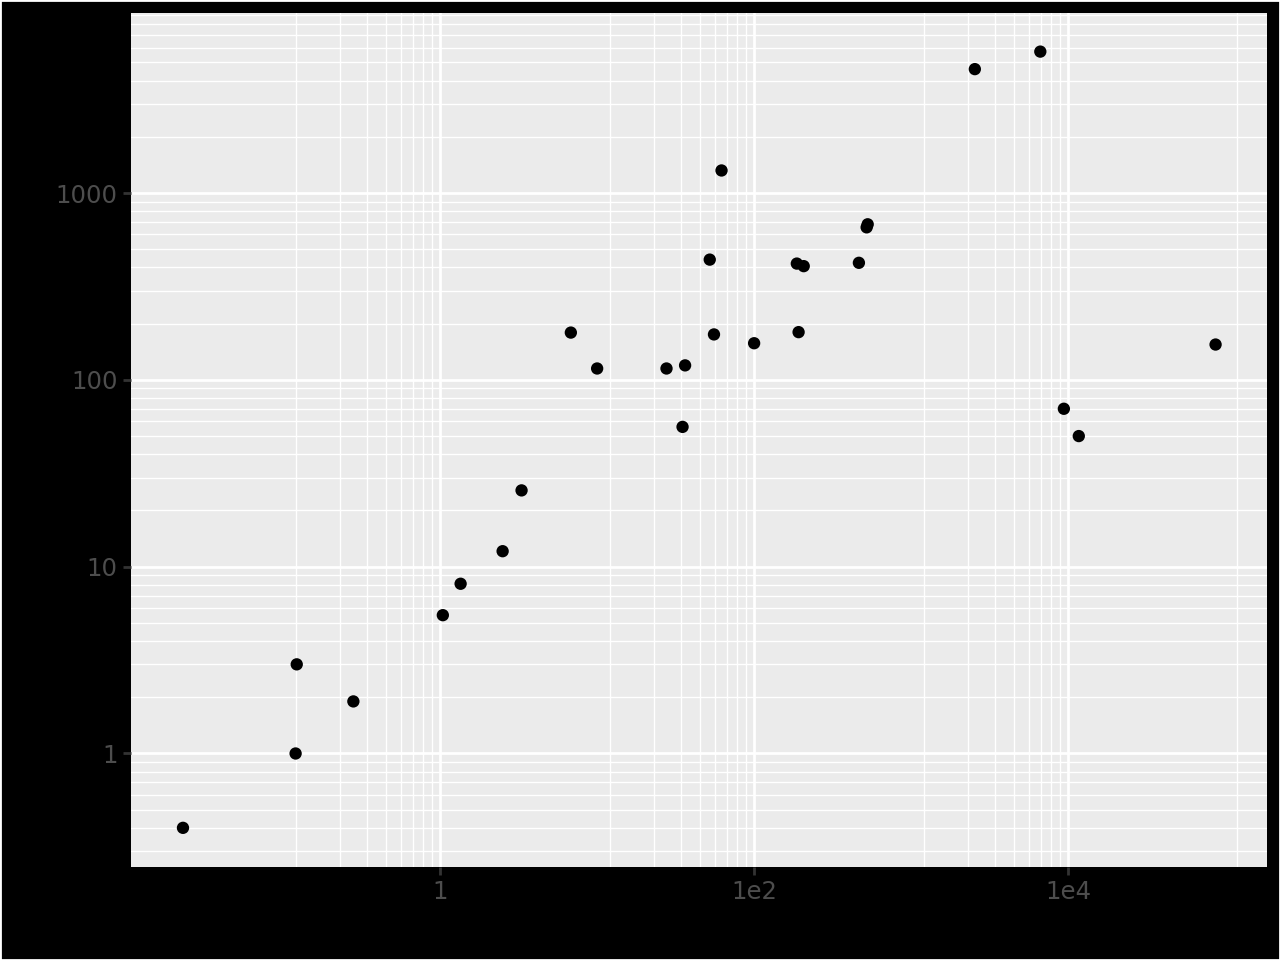

In [14]:
# Using log scale now
(ggplot(dt, aes(x='body_weight', y='brain_weight')) +
geom_point() +
scale_x_log10() + scale_y_log10()).show()

3. From these graphical investigations, you decide to model the relationship between body and brain
weights on a logarithmic scale. Update the data table as follows: Fit now a linear regression. Does the fit make more sense? Nonetheless do you trust the p-values? Suggest
a diagnostic plot and comment

In [18]:
dt['log10_brain_weight'] = np.log10(dt['brain_weight'])
dt['log10_body_weight'] = np.log10(dt['body_weight'])

In [19]:
fit2 = smf.ols('log10_brain_weight ~ log10_body_weight', data=dt).fit()
print(fit2.summary2().tables[1])
# The slop is now positive which makes sense


                      Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
Intercept          1.109578  0.179423  6.184143  0.000002  0.740769  1.478388
log10_body_weight  0.495995  0.078169  6.345126  0.000001  0.335315  0.656674


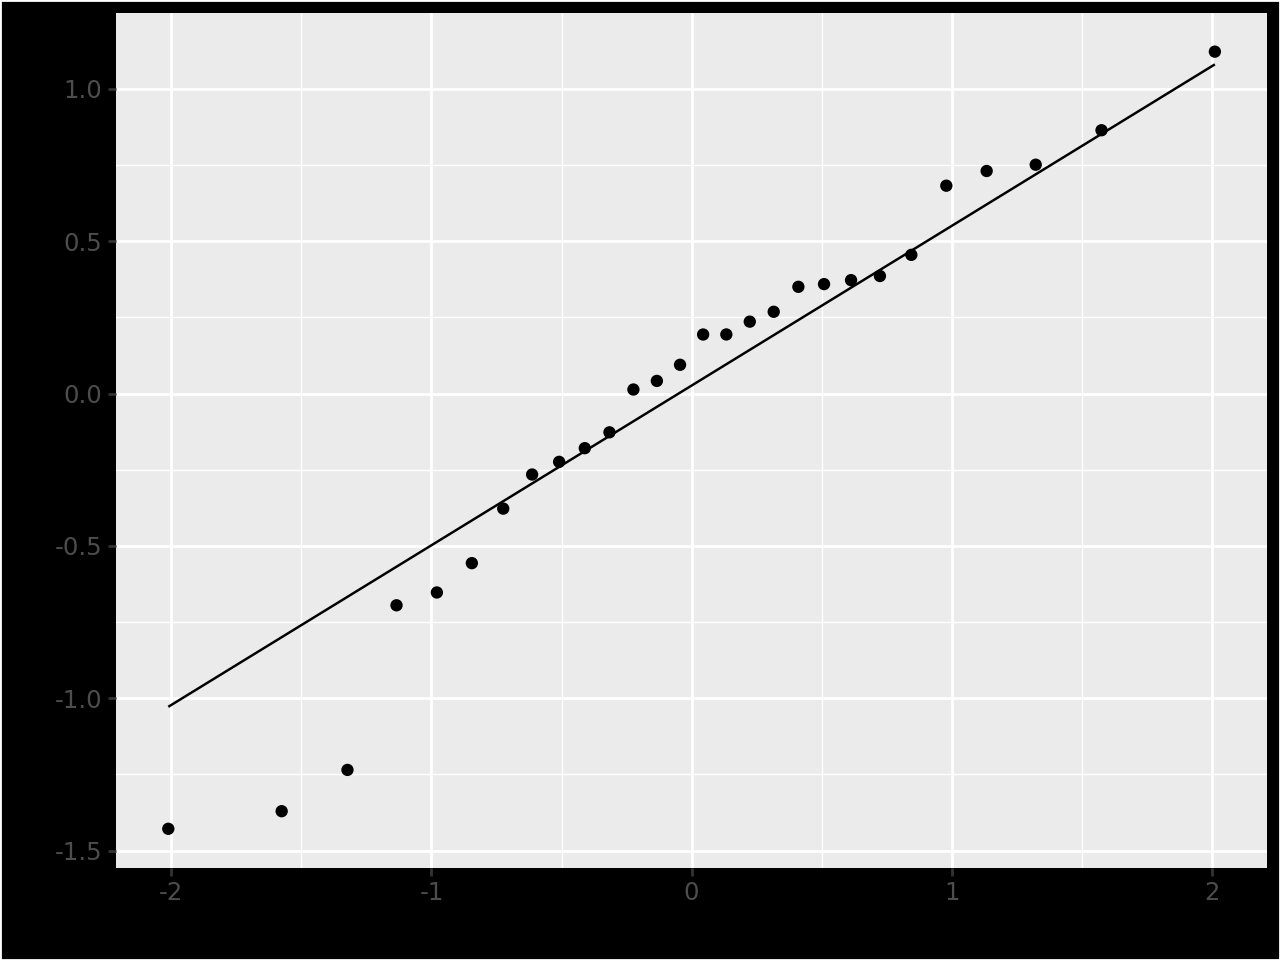

In [20]:
# We need a qq plot of the residuals to confirm the validity of the plot here.
dt['res2'] = fit2.resid
(ggplot(dt, aes(sample='res2')) + stat_qq() + stat_qq_line()).show()

# As we can see there are clear points (first three pointes) that are deviating from the normal distribution

4. Which data points are leading to a deviation from the statistical assumptions of linear regression?
Comment. Remove them from the dataset and re-iterate. Are assumptions now met or are there new
problematic data points standing out? Which ones? Comment.

In [23]:
# We found out that the dinosaurs in the dataset are causing the problem
dt_no_dino = dt[
~dt['name'].isin(["Brachiosaurus", "Dipliodocus", "Triceratops"])
].copy()

fit3 = smf.ols('log10_brain_weight ~ log10_body_weight', data=dt_no_dino).fit()
print(fit3.summary2().tables[1])

                      Coef.  Std.Err.          t         P>|t|    [0.025  \
Intercept          0.933912  0.087121  10.719710  2.027682e-10  0.753689   
log10_body_weight  0.752261  0.045719  16.454141  3.242750e-14  0.657685   

                     0.975]  
Intercept          1.114136  
log10_body_weight  0.846837  


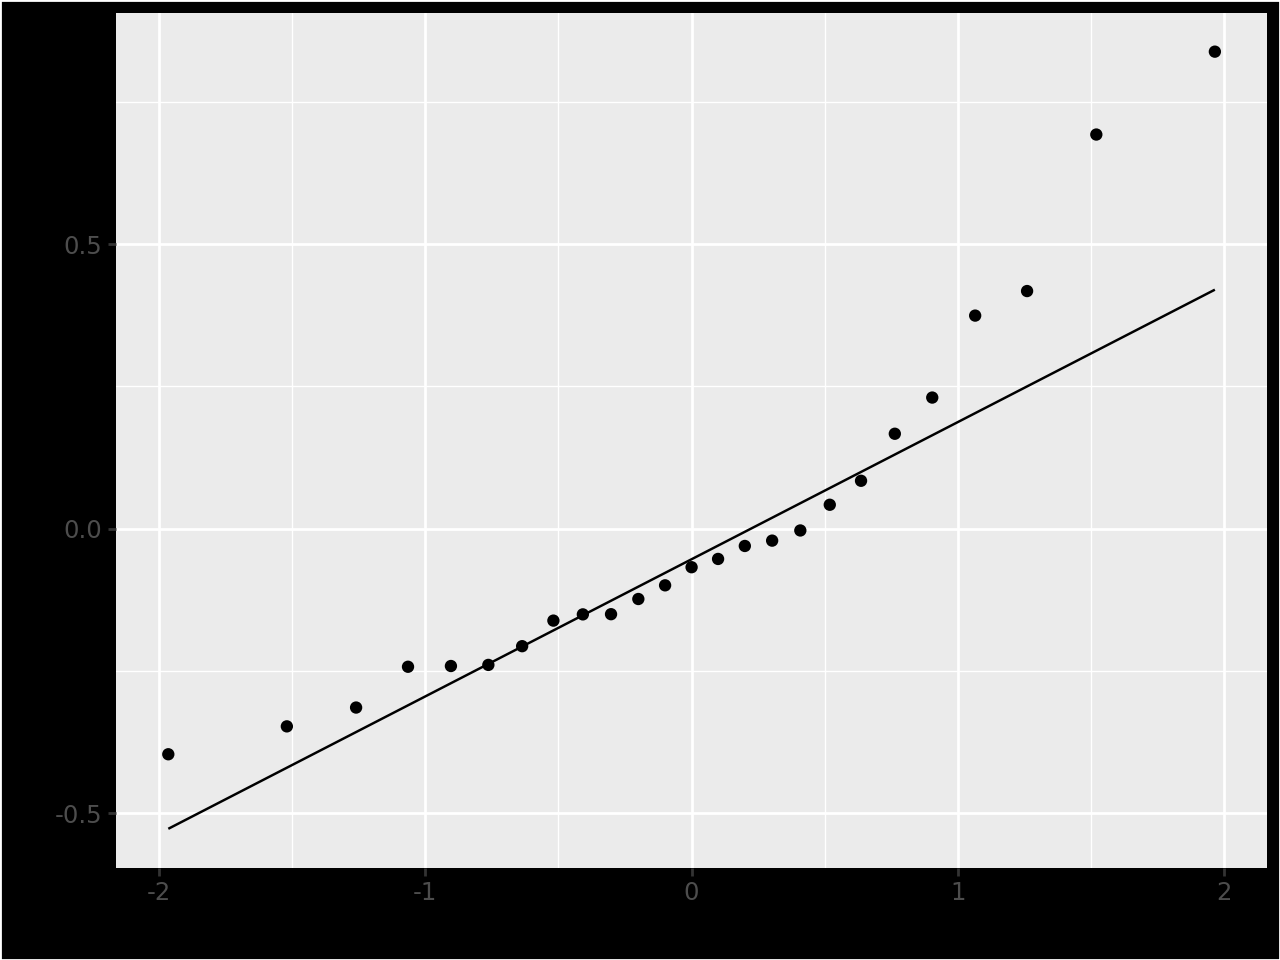

In [24]:
dt_no_dino['res3'] = fit3.resid
(ggplot(dt_no_dino, aes(sample='res3')) + stat_qq() + stat_qq_line()).show()

# Now we find outliers in the tail

In [25]:
print(dt_no_dino.sort_values('res3', ascending=False).head())

## Primates are the next problem. Now removing the primates
dt_no_dino_no_primate = dt_no_dino[
~dt_no_dino['name'].isin(["Human", "Rhesus monkey", "Chimpanzee", "Potar monkey"])
].copy()
fit4 = smf.ols('log10_brain_weight ~ log10_body_weight', data=dt_no_dino_no_primate).fit()

                        name  body_weight  brain_weight  log10_brain_weight  \
rownames                                                                      
Human                  Human       62.000        1320.0            3.120574   
Rhesus monkey  Rhesus monkey        6.800         179.0            2.252853   
Chimpanzee        Chimpanzee       52.160         440.0            2.643453   
Potar monkey    Potar monkey       10.000         115.0            2.060698   
Mole                    Mole        0.122           3.0            0.477121   

               log10_body_weight      res2      res3  
rownames                                              
Human                   1.792392  1.121979  0.838316  
Rhesus monkey           0.832509  0.730355  0.692677  
Chimpanzee              1.717338  0.682084  0.417655  
Potar monkey            1.000000  0.455125  0.374525  
Mole                   -0.913640 -0.179296  0.230505  


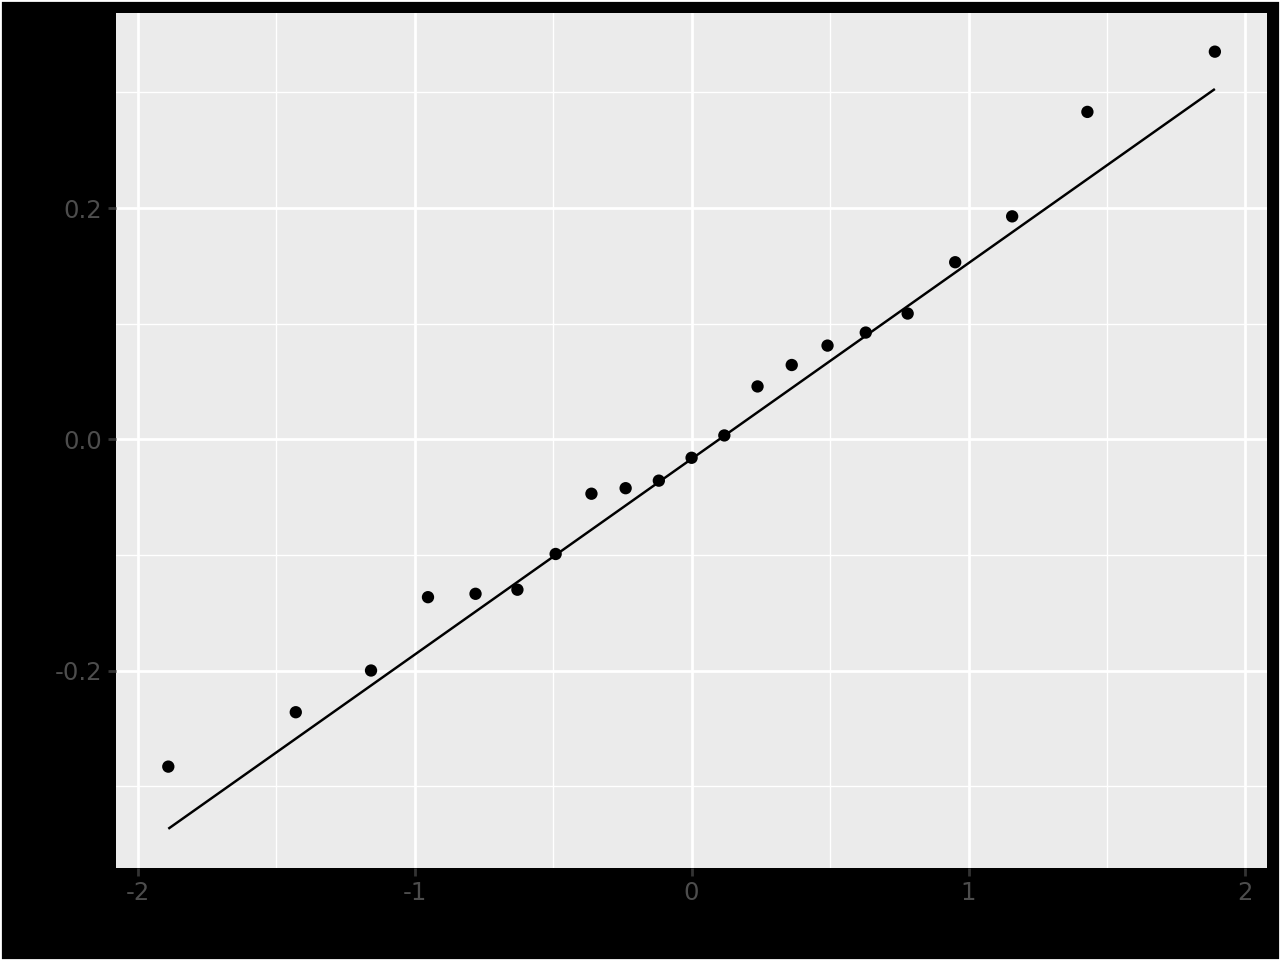

In [27]:
dt_no_dino_no_primate['res4'] = fit4.resid
(ggplot(dt_no_dino_no_primate, aes(sample='res4')) + stat_qq() + stat_qq_line()).show()

5. Suggest an alternative way independent of the Gaussian assumptions to estimate 95% confidence
intervals of the slope on the full dataset. Implement it. What do you find for the full dataset? How does
it compare to the 95% confidence interval returned by linear regression? Hint: for the latter apply the
conf_int() method to the fitted model object.

In [29]:
# bootstrapping with replacement
R = 1000
slope_bootstrap = np.zeros(R)
for i in range(R):
    dt_rnd = dt.sample(n=len(dt), replace=True)
    fit_rnd = smf.ols('log10_brain_weight ~ log10_body_weight', data=dt_rnd).fit()
    slope_bootstrap[i] = fit_rnd.params['log10_body_weight']
conf_int_bootstrap = np.quantile(slope_bootstrap, [0.025, 0.975])
print(conf_int_bootstrap)


[0.29939421 0.75928197]


In [28]:
conf_int_lm = fit2.conf_int(alpha=0.05).loc['log10_body_weight']
print(conf_int_lm)

0    0.335315
1    0.656674
Name: log10_body_weight, dtype: float64
